In [1]:
import pandas as pd
import numpy as np

# PREPROCESAMIENTO Y EDA

In [31]:
rtp = pd.read_csv("C:/Hackathon CDMX/Data/RTP/_rtp_afluencia_desglosado_04_2026.csv", 
                  encoding='utf-8', 
                  encoding_errors='ignore')

print(rtp.shape)
rtp.head()


(38589, 6)


,fecha,mes,anio,servicio,tipo_pago,afluencia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0


> se visualiza que no es necesario saber el tipo de pago de las personas para este reto, solo la afluencia del dia

In [32]:
# Crear columna 'dia' extrayendo el día de la fecha
rtp['dia'] = pd.to_datetime(rtp['fecha'], format='%Y-%m-%d').dt.day

# Agrupar por fecha, servicio, dia, mes y anio, sumando la afluencia
df_rtp = rtp.groupby(['fecha', 'servicio', 'dia', 'mes', 'anio'], as_index=False)['afluencia'].sum()

# Verificar resultado
print(df_rtp.shape)
df_rtp.head()


(12763, 6)


,fecha,servicio,dia,mes,anio,afluencia
0,2022-01-01,Atenea,1.0,Enero,2022.0,3169.0
1,2022-01-01,Ecoatenea,1.0,Enero,2022.0,0.0
2,2022-01-01,Ecobús,1.0,Enero,2022.0,6945.0
3,2022-01-01,Expdirecto,1.0,Enero,2022.0,52.0
4,2022-01-01,Expreso,1.0,Enero,2022.0,18375.0


In [33]:
# Crear un DataFrame con el conteo y el porcentaje de nulos
missing_data = pd.DataFrame({
    'Nulos': df_rtp.isnull().sum(),
    'Porcentaje': (df_rtp.isnull().mean() * 100).round(2)
})

# Filtrar solo las columnas que tienen al menos un valor nulo
missing_data = missing_data[missing_data['Nulos'] > 0].sort_values(by='Nulos', ascending=False)

print(missing_data)

Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []


In [34]:
df_rtp.info()

<class 'pandas.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      12763 non-null  str    
 1   servicio   12763 non-null  str    
 2   dia        12763 non-null  float64
 3   mes        12763 non-null  str    
 4   anio       12763 non-null  float64
 5   afluencia  12763 non-null  float64
dtypes: float64(3), str(3)
memory usage: 921.6 KB


In [35]:
# Convertir fecha de string a formato fecha (datetime)
df_rtp['fecha'] = pd.to_datetime(df_rtp['fecha'], format='%Y-%m-%d')

# Convertir valores flotantes a enteros
df_rtp['dia'] = df_rtp['dia'].astype(int)
df_rtp['anio'] = df_rtp['anio'].astype(int)
df_rtp['afluencia'] = df_rtp['afluencia'].astype(int)

In [36]:
df_rtp.info()
df_rtp.head(1)

<class 'pandas.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fecha      12763 non-null  datetime64[us]
 1   servicio   12763 non-null  str           
 2   dia        12763 non-null  int64         
 3   mes        12763 non-null  str           
 4   anio       12763 non-null  int64         
 5   afluencia  12763 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 795.4 KB


,fecha,servicio,dia,mes,anio,afluencia
0,2022-01-01,Atenea,1,Enero,2022,3169


In [37]:
df_rtp.describe()

,fecha,dia,anio,afluencia
count,12763,12763.000000,12763.000000,12763.000000
mean,2024-01-22 07:09:18.207318,15.711196,2023.583484,37373.648045
min,2022-01-01 00:00:00,1.000000,2022.000000,0.000000
25%,2022-12-21 00:00:00,8.000000,2022.000000,1799.500000
50%,2024-01-12 00:00:00,16.000000,2024.000000,16575.000000
75%,2025-02-06 00:00:00,23.000000,2025.000000,58526.000000
max,2026-04-30 00:00:00,31.000000,2026.000000,263939.000000
std,NaN,8.791680,1.242681,46855.129485


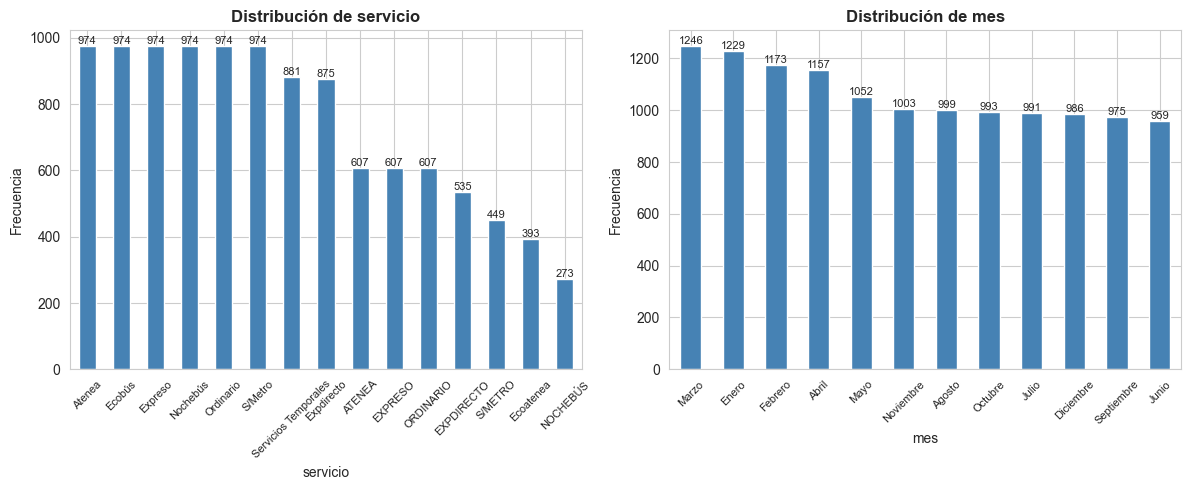


Total de variables categóricas: 2
Variables: servicio, mes


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas (tipo object/string)
categorical_cols = df_rtp.select_dtypes(include=['str']).columns.tolist()

# Configurar el estilo
sns.set_style("whitegrid")

# Crear gráficos de barras para cada variable categórica
n_cols = len(categorical_cols)
n_rows = (n_cols + 2) // 3  # 3 gráficos por fila

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(categorical_cols):
    # Contar valores y tomar los top 15 (para evitar gráficos muy saturados)
    value_counts = df_rtp[col].value_counts().head(15)
    
    # Crear gráfico de barras
    ax = axes[idx]
    value_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Añadir valores en las barras
    for i, v in enumerate(value_counts):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

# Ocultar ejes vacíos si hay menos gráficos que subplots
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Mostrar resumen de variables categóricas
print(f"\nTotal de variables categóricas: {n_cols}")
print(f"Variables: {', '.join(categorical_cols)}")


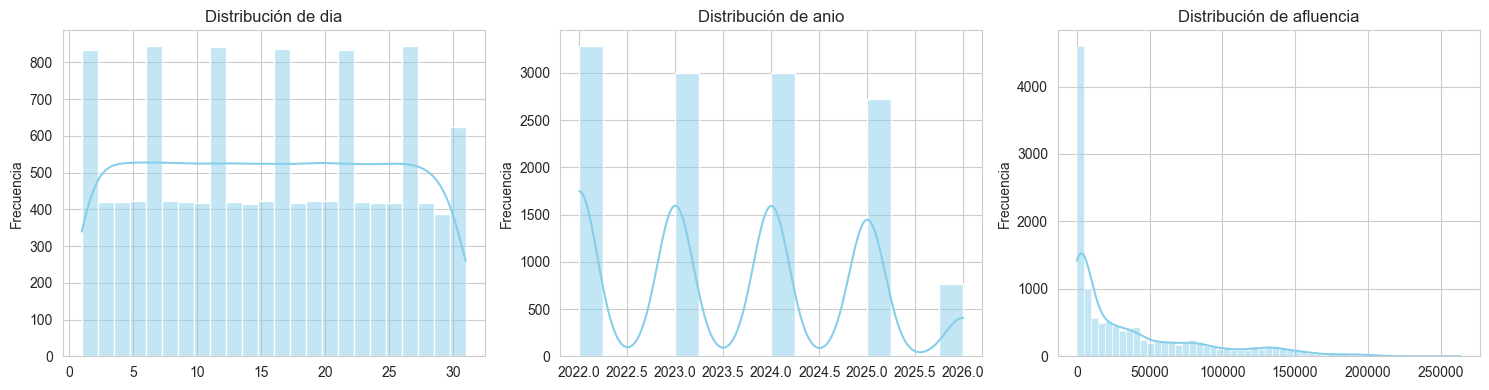

In [39]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar solo las columnas numéricas de tu DataFrame
df_numericas = df_rtp.select_dtypes(include=["number"])
columnas = df_numericas.columns
num_columnas = len(columnas)

# 2. Configurar la cuadrícula de gráficos de forma dinámica
columnas_cuadricula = 3  # Número de gráficos por fila
filas_cuadricula = math.ceil(num_columnas / columnas_cuadricula)

# Definir el tamaño de la figura según la cantidad de filas
fig, axes = plt.subplots(
    filas_cuadricula,
    columnas_cuadricula,
    figsize=(5 * columnas_cuadricula, 4 * filas_cuadricula),
)
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# 3. Dibujar un histograma para cada variable numérica
for i, col in enumerate(columnas):
    sns.histplot(data=df_rtp, x=col, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("")  # Quita etiquetas repetitivas para limpiar el diseño
    axes[i].set_ylabel("Frecuencia")

# 4. Ocultar los subgráficos vacíos (si el número de variables no es múltiplo de 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espacio para que no se encimen los textos
plt.tight_layout()
plt.show()


>No hacer nada con los outliers de afluencia porque ese `0` significa que ese dia no funciono el transporte

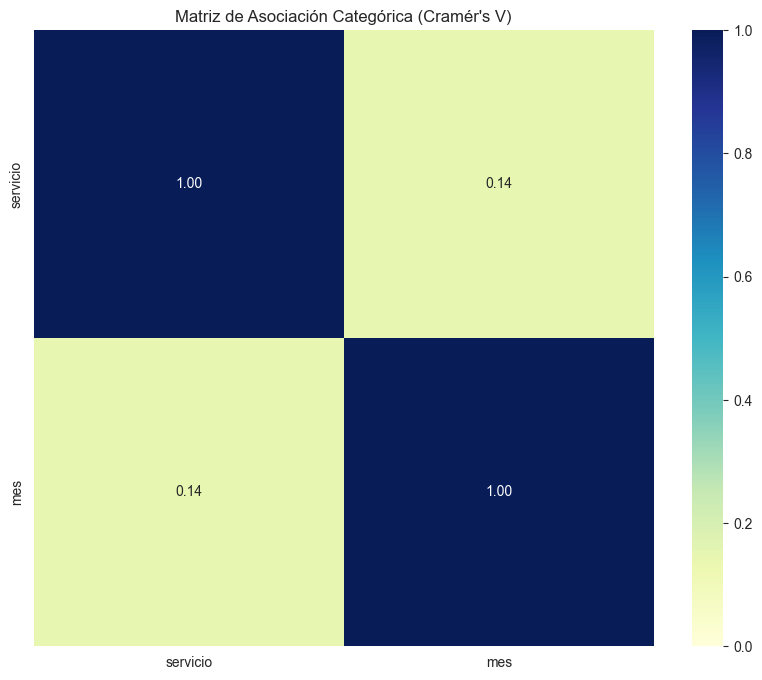

In [40]:
from scipy.stats import chi2_contingency

# 1. Función para Cramér's V (Asociación Categórica)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Matriz de Asociación Categórica (Cramér's V)
if len(categorical_cols) > 1:
    v_results = []
    for col1 in categorical_cols:
        row = []
        for col2 in categorical_cols:
            row.append(cramers_v(df_rtp[col1], df_rtp[col2]))
        v_results.append(row)
    
    v_matrix = pd.DataFrame(v_results, index=categorical_cols, columns=categorical_cols)

    plt.figure(figsize=(10, 8))
    sns.heatmap(v_matrix, annot=True, cmap='YlGnBu', fmt=".2f", vmin=0, vmax=1)
    plt.title("Matriz de Asociación Categórica (Cramér's V)")
    plt.show()

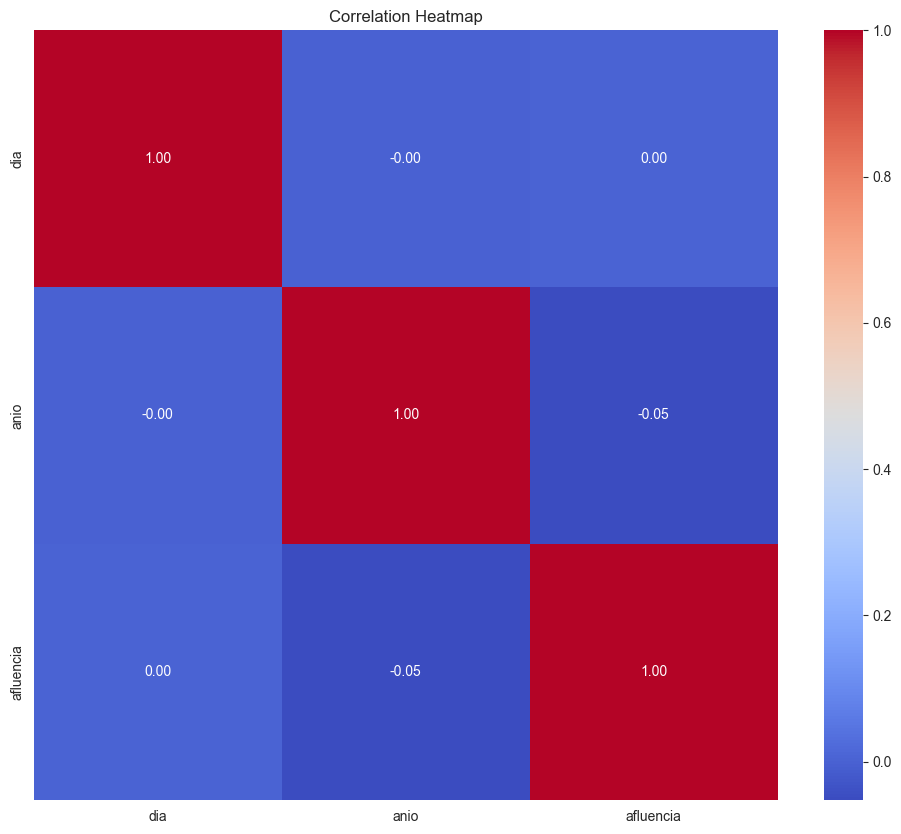

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

C = df_numericas.corr()

plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(C, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [43]:
import pandas as pd

# Crear un DataFrame con el conteo de ceros y el porcentaje general
ceros = pd.DataFrame({
    'Ceros': (df_rtp == 0).sum(),
    'Porcentaje': ((df_rtp == 0).mean() * 100).round(2)
})

# Filtrar solo las columnas que tienen al menos un cero y ordenar de mayor a menor
ceros = ceros[ceros['Ceros'] > 0].sort_values(by='Ceros', ascending=False)

print(ceros)


           Ceros  Porcentaje
afluencia    298        2.33


# CREACION NUEVO DF

In [47]:
# 1. Filtrar los datos (Crea una copia explícita para evitar advertencias de pandas)
df_rtp_final = df_rtp[df_rtp['afluencia'] > 0].copy()

# 2. Imprimir el mensaje (Se eliminaron los paréntesis de .shape)
print(f"Se subirán {df_rtp_final.shape[0]} filas de {df_rtp.shape[0]}")

# 3. Guardar el archivo (Se agregó la 'r' para validar la ruta en Windows)
df_rtp_final.to_csv(r'C:\Hackathon CDMX\clean_data\afluencia_rtp.csv', index=False)


Se subirán 12465 filas de 12763
